In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'
housing = pd.read_csv(data_url+'housing.csv')

In [27]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [28]:
#열 이름 확인

housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [29]:
#자료형과 결측치 확인
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [30]:
#수치형 특성 : 기술 통계량
#describe()메서드는 수치형 열의 개수 평균 표준편차 최솟값 사분위수 최댓값을 한 눈에 보여준다.

#ex) housing의 열의 개수, 평균, 표준편차, 최솟값, 사분위수, 최댓값을 출력하는 코드를 작성하라

housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


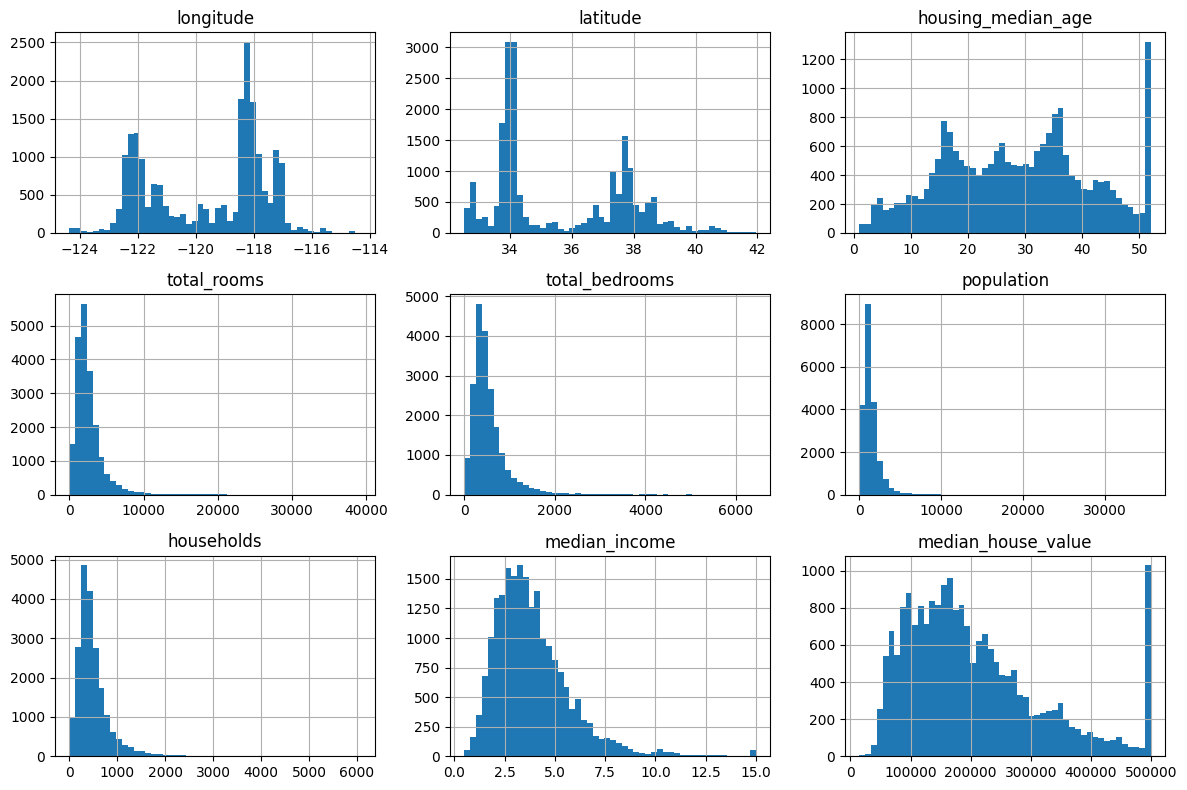

In [31]:
#수치형 특성 : 히스토그램

#hist() 메서드로 모든 수치형 열의 히스토그램 한꺼번에 그려보면 분포 파악 가능

housing.hist(bins=50, figsize=(12,8))
plt.tight_layout()
plt.show()

In [32]:
#범주형 특성 : 해안 근접도

#고유값 확인
ocean_proximity_values=housing["ocean_proximity"].unique()
ocean_proximity_values

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [33]:
#각 범주의 빈도 확인
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

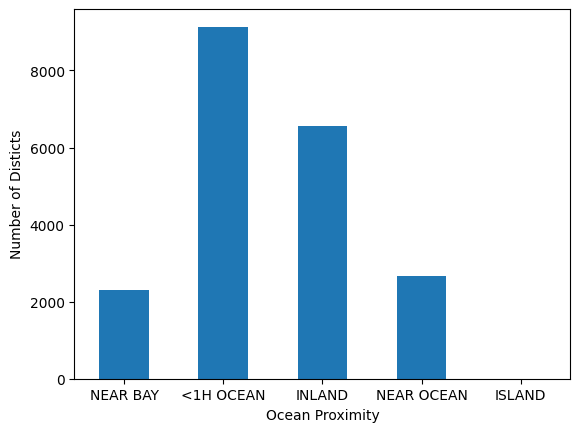

In [34]:
housing["ocean_proximity"].value_counts().loc[ocean_proximity_values].plot(kind='bar', rot=0)
plt.xlabel("Ocean Proximity")
plt.ylabel("Number of Disticts")
plt.show()

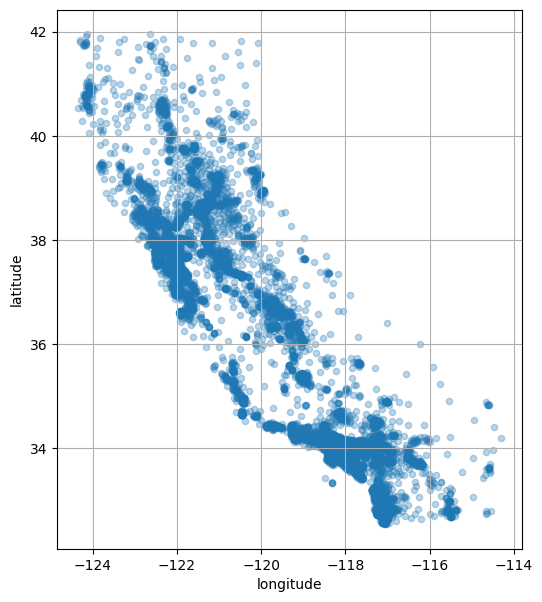

In [35]:
# 4단계 : 시각화를 통한 탐색

housing.plot(kind="scatter",
              x="longitude",
              y="latitude",
              grid=True,
              alpha=0.3,
              figsize=(6,7))

plt.show()

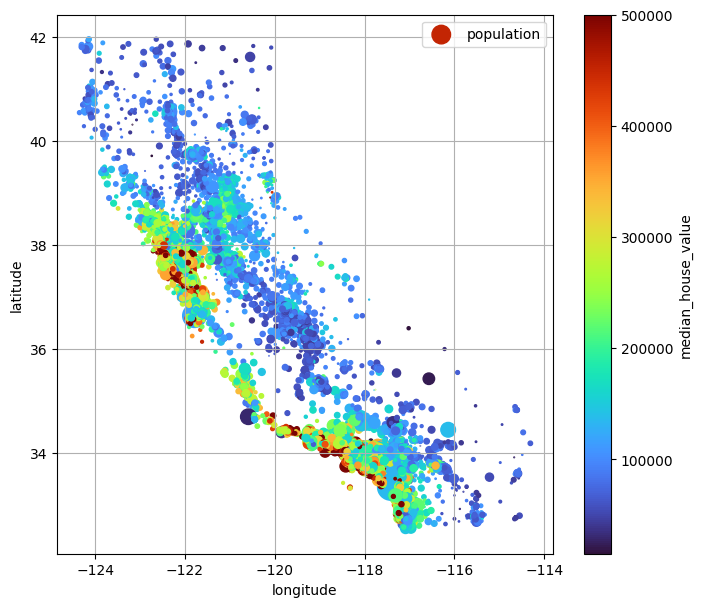

In [36]:
ax=housing.plot(kind="scatter",x="longitude",y="latitude",grid=True,s=housing["population"]/100, label="population", c="median_house_value", cmap="turbo", colorbar=True, figsize=(8,7))

In [37]:
#해안 근접도 시각화

#pd.factorize가 범주를 숫자로 변환
pd.factorize(housing["ocean_proximity"])

(array([0, 0, 0, ..., 2, 2, 2], shape=(20640,)),
 Index(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'], dtype='str'))

In [38]:
housing["ocean_p"]=pd.factorize(housing["ocean_proximity"])[0]
#범주를 숫자로 변환한 어레이만 지정해
#housing 데이터에 새로운 열 추가

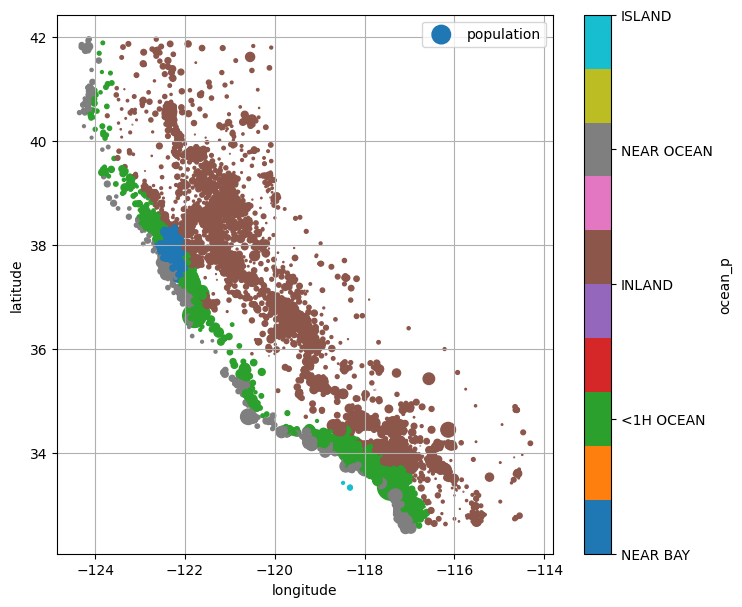

In [ ]:
ax=housing.plot(kind="scatter",
                x="longitude",
                y="latitude",
                grid=True,
                s=housing["population"]/100, label="population",
                c="ocean_p",
                cmap="tab10",
                colorbar=True,
                figsize=(8,7))

#table10은 색상 뚜렷 구분 컬러맵
#컬러바의 눈금에 범주명을 표시

cb=ax.collections[0].colorbar #컬러바에 사용할 데이터 설정
cb.set_ticks([0,1,2,3,4])# 눈금 어디에 설치할지 지정
cb.set_ticklabels(housing["ocean_proximity"].unique()) #눈금명 ocean_proximity에 있는 값으로 결정

plt.show()

In [46]:
#5단계 상관관계 분석

#피어슨 상관계수 : 두 특성 사이의 선형 관계 강도를 -1에서 1 사이 값으로 나타냄

#1에 가까우면 양, -1에 가까우면 음, 0에 가까우면 비선형

corr_matrix=housing.loc[:,['median_income','median_house_value']].corr()

corr_matrix

,median_income,median_house_value
median_income,1.000000,0.688075
median_house_value,0.688075,1.000000


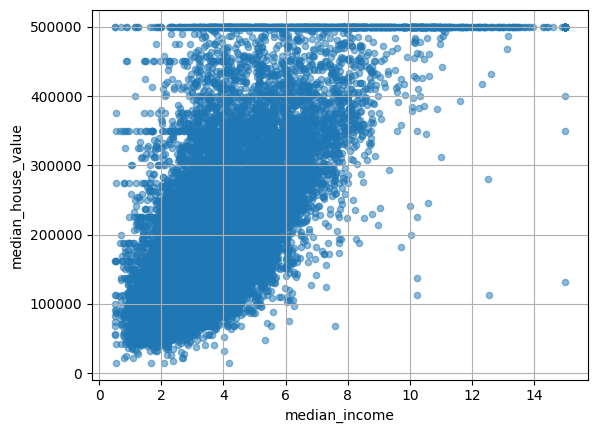

In [ ]:
housing.plot(kind="scatter",
             x="median_income",
             y="median_house_value",
             alpha=0.5,
             grid=True)

plt.show()

#50만달러 부근에서 일직선 형성 => 데이터를 일부러 쳐냈다

#이러한 패턴 발견, EDA의 가치

In [53]:
cols=['median_house_value','median_income', 'total_rooms', 'housing_median_age']
housing[cols].corr()

,median_house_value,median_income,total_rooms,housing_median_age
median_house_value,1.000000,0.688075,0.134153,0.105623
median_income,0.688075,1.000000,0.198050,-0.119034
total_rooms,0.134153,0.198050,1.000000,-0.361262
housing_median_age,0.105623,-0.119034,-0.361262,1.000000


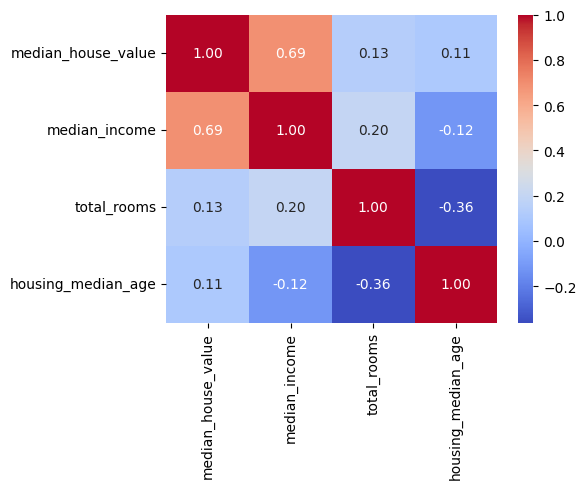

In [54]:
corr=housing[cols].corr()

fig, ax= plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
#median_house_value와 관련된 상관 관계를 출력한다.
housing[cols].corr()['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
Name: median_house_value, dtype: float64

In [56]:
#6단계 : 데이터 전처리

#이상치 : 50만 달러 부근 비정상적 데이터
#결측치 : total_bedrooms열의 누락값 207

housing.median_house_value.value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
327900.0      1
438800.0      1
455500.0      1
200700.0      1
47000.0       1
Name: count, Length: 3842, dtype: int64